In [1]:
nom et prenom : toubouh loubna
master : génie logiciel pour le cloud
tp : J’ai implémenté et comparé des modèles des régression lineaire,multiple,polynomiale et logistique from scratch et avec la bibliothéque sklearn en utilisant la descente de gradient, puis évalué leurs performances avec MSE et des visualisations."

SyntaxError: invalid character '’' (U+2019) (459808026.py, line 3)

In [45]:
import pandas as pd  # pour manipuler les données
import numpy as np    # pour les calculs numériques
import matplotlib.pyplot as plt  #pour dessiner les graphiques
# bibliothèques de sklearn pour le machine learning
from sklearn.linear_model import LinearRegression  # modèle de régression linéaire
from sklearn.preprocessing import PolynomialFeatures, StandardScaler # pour polynôme et normalisation

data = pd.read_csv("Food_Delivery_Times.csv") # Charger le dataset depuis un fichier CSV
data = data.drop(columns=["Order_ID", "Weather", "Traffic_Level", "Time_of_Day","Vehicle_Type"]) #suppression des colonne inutiles
data  # Afficher le dataset après nettoyage


,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,12,1.0,43
1,16.42,20,2.0,84
2,9.52,28,1.0,59
3,7.44,5,1.0,37
4,19.03,16,5.0,68
...,...,...,...,...
995,8.50,13,3.0,54
996,16.28,8,9.0,71
997,15.62,26,2.0,81
998,14.17,8,0.0,55


In [46]:
x = data['Distance_km'].to_numpy()   # Extraire la variable explicative et convertit la colonne Distance_km en tableau NumPy pour les calculs mathématiques
y = data['Delivery_Time_min'].to_numpy()  #Extraire la variable cible et convertit la colonne Delivery_Time_min en tableau NumPy
print(x.shape)
print(y.shape)

(1000,)
(1000,)


a = 3.025871676498248
b = 26.291821710380674


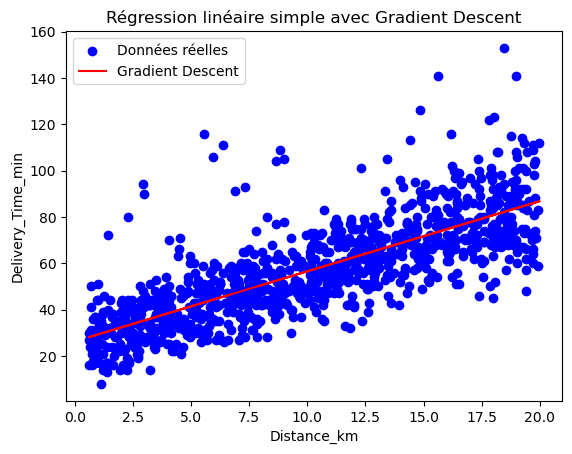

In [47]:
# la Regression linéaire From scratch
#nombre de point dans la liste x
n = len(x)
#initialisation au hasard de a et b
a = np.random.randn()
b = np.random.randn()
#initialisation de paramètres  Gradient Descent    
alpha = 0.01
iteration = 10000    
#Boucle Gradient Descent
for i in range(iteration):
    y_pred = a*x + b  #calcule de des predictions
    da = -(1/n) * np.sum(x * (y - y_pred))  #dérivée de a
    db = -(1/n) * np.sum(y - y_pred)  #dérivée de b 
    #mise a jour de a et b  
    a = a - alpha * da     
    b = b - alpha * db
print("a =", a) #affichage de la pente final
print("b =", b) #affichage de l'ordonnée à l'origine
#Tracer la droite
plt.scatter(x, y, color='blue', label='Données réelles')  #la creation d'une nuage de points
plt.plot(x, a*x + b, color='red', label='Gradient Descent') #droite de regression
plt.xlabel("Distance_km")    # Nom de l’axe des abscisses axe X
plt.ylabel("Delivery_Time_min") # Nom de l’axe des ordonnées axe Y
plt.title("Régression linéaire simple avec Gradient Descent")
plt.legend()    # affiche les labels définis
plt.show()   # Afficher le graphique







Intercept (b) : 26.29182171119828
Coefficient (a) : [3.02587168]


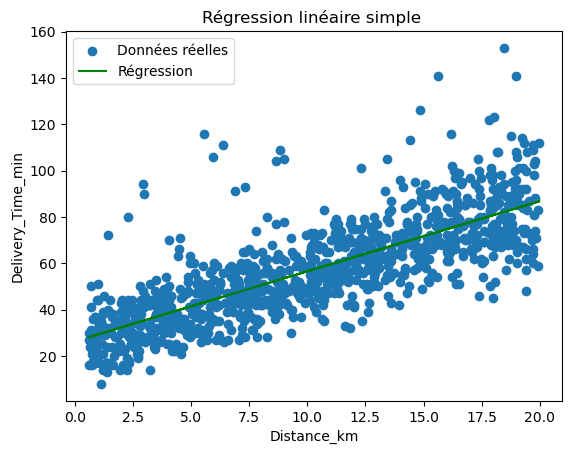

In [48]:

#La régression linéaire simple avec sklearn

X = data[['Distance_km']]   # Définir la variable explicative indépendante 
y = data['Delivery_Time_min'] # Définir la variable cible à prédire
model = LinearRegression()   # Création du modèle
model.fit(X, y) # Entraînement sur toutes les données
y_pred = model.predict(X)

# Affichage des paramètres
print("Intercept (b) :", model.intercept_)
print("Coefficient (a) :", model.coef_)

# Visualisation
plt.scatter(X, y, label="Données réelles")
plt.plot(X, y_pred, color='green', label="Régression")
plt.xlabel("Distance_km")
plt.ylabel("Delivery_Time_min")
plt.title("Régression linéaire simple ")
plt.legend()
plt.show()







In [49]:
data = data.dropna()


Theta = [ 6.94500793  3.1690231   1.11154136 -0.30805786]


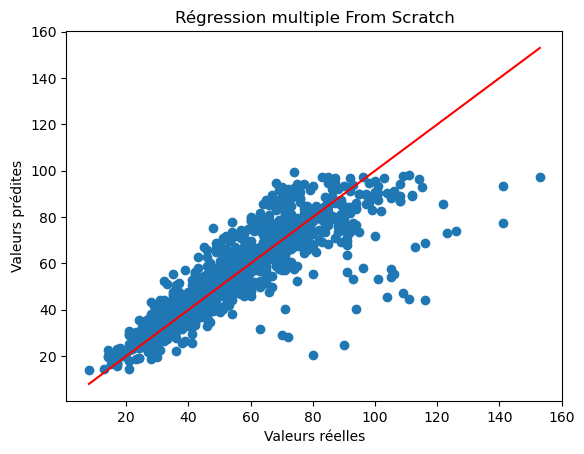

In [50]:
#la Regression Multiple From scratch

X_multi = data.drop("Delivery_Time_min", axis=1).values   # Supprime la colonne "Delivery_Time_min" du Dataset pour prendre toutes les colonnes sauf la cible
y = data["Delivery_Time_min"].values     #la prediction de y
m = len(y)                      #nombre de données
X_b = np.c_[np.ones((m,1)), X_multi]  # ajouter une colonne de 1 à gauche de X
n = X_b.shape[1]
theta = np.zeros(n)             #initialise theta a zero
alpha = 0.001                   # le pas
iterations = 10000            # nombre d’itérations de la descente de gradient
for i in range(iterations):    # descente de gradient
    y_pred = X_b.dot(theta)   # la valeur prédite par la droite actuelle
    gradient = (1/m) * X_b.T.dot(y_pred - y)
    theta = theta - alpha * gradient  # mettre a jour a theta  
print("Theta =", theta)    # affiche les coefficients appris
y_pred = X_b.dot(theta)   # les prédictions finales
plt.scatter(y, y_pred)    # points réel vs prédit
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')   #ligne rouge c'est le modèle parfait
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression multiple From Scratch")
plt.show()



Intercept (b) : 12.570161875484061
Coefficients (a1, a2, ...) : [ 3.02688213  0.9603704  -0.56536551]


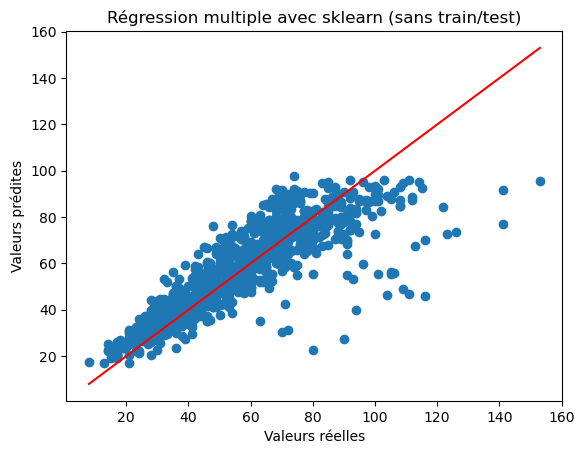

In [51]:
#la Regression Multiple avec sklearn

X = data.drop("Delivery_Time_min", axis=1) # définir les variables explicatives toutes les colonnes sauf la cible
y = data["Delivery_Time_min"]   #Définir la variable cible ce que le modèle doit prédire
model = LinearRegression() # Création du modèle
model.fit(X, y) # Entraînement sur TOUTES les données
y_pred = model.predict(X) # Prédictions sur les mêmes données
# Affichage des paramètres
print("Intercept (b) :", model.intercept_)
print("Coefficients (a1, a2, ...) :", model.coef_)
# Visualisation
plt.scatter(y, y_pred) #comparer les valeurs réelles et prédites
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red') # ligne de référence le bon modèle
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression multiple avec sklearn (sans train/test)")
plt.show()

Theta = [ 1.19697641e+00  4.71717865e+00 -1.17834144e-03]


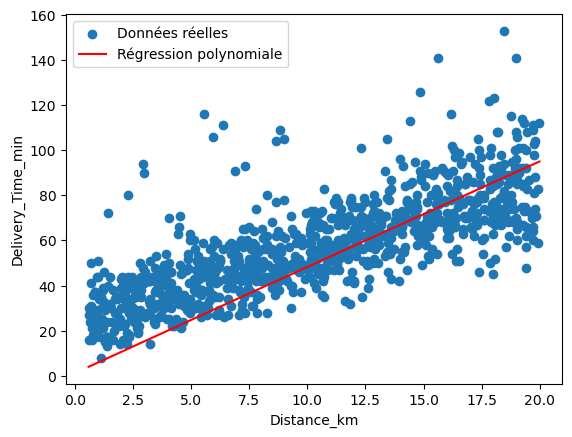

In [52]:
#la regression polynomiale from scratch

x = data["Distance_km"].values # la variable indépendante
y = data["Delivery_Time_min"].values #la variable cible
m = len(x)    # nbr d'exemples
X_poly = np.c_[x, x**2] # features polynomiales (x et x²) on les crée pour capturer une relation non linéaire
X_b = np.c_[np.ones((m,1)), X_poly]  # ajout biais
theta = np.zeros(X_b.shape[1]) # initialisation
# gradient descent
alpha =  0.00001
iterations = 10000
for i in range(iterations):
    y_pred = X_b.dot(theta)  # calcule de prédictions
    gradient = (1/m) * X_b.T.dot(y_pred - y) # calcule de gradient
    theta = theta - alpha * gradient # mise a jour de theta 
print("Theta =", theta)
#visualisation
x_sorted = np.sort(x) # tri des données pour tracer une courbe propre
X_poly_sorted = np.c_[x_sorted, x_sorted**2]   # features polynomiales triées
X_b_sorted = np.c_[np.ones((len(x_sorted),1)), X_poly_sorted] # ajout biais
y_pred_sorted = X_b_sorted.dot(theta)  #calcule de prédictions 

plt.scatter(x, y, label="Données réelles") # points réels du dataset
plt.plot(x_sorted, y_pred_sorted, color='red', label="Régression polynomiale")

plt.xlabel("Distance_km")
plt.ylabel("Delivery_Time_min")
plt.legend()
plt.show()

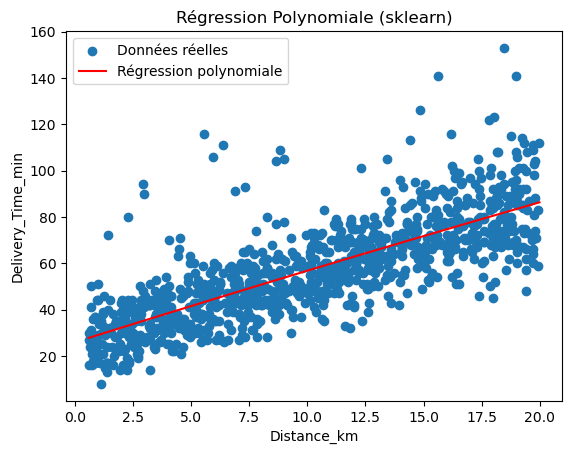

In [53]:
#la regression polynomiale sklearn

x = data['Distance_km'].values.reshape(-1,1)  
y = data['Delivery_Time_min'].values

poly = PolynomialFeatures(degree=2)  # Création des variables polynomiales de degré 2
X_poly = poly.fit_transform(x)    # Transformation polynomiale (ajoute 1, x, x²)
model = LinearRegression()    #crée un modèle de régression
model.fit(X_poly, y)   # Le modèle cherche les meilleurs theta pour minimiser l’erreur
x_sorted = np.sort(x, axis=0)
X_poly_sorted = poly.transform(x_sorted)  # transforme x trié en format 2D puis génère les variables polynomiales (x, x**2, ...)
y_pred_sorted = model.predict(X_poly_sorted)    #prédictions correspondantes aux x triés
#Visualisation
plt.scatter(x, y, label="Données réelles")
plt.plot(x_sorted, y_pred_sorted, color='red', label="Régression polynomiale")
plt.xlabel("Distance_km")
plt.ylabel("Delivery_Time_min")
plt.title("Régression Polynomiale (sklearn)")
plt.legend()
plt.show()


In [54]:
# Régression logistique 

# On crée les données d’entrée X
# Chaque ligne représente une combinaison de deux variables (0 ou 1)
# on utilise la logique OR
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
y = np.array([0,1,1,1])   # au moins une des entrées vaut 1
X = np.c_[np.ones(X.shape[0]), X]   # On ajoute une colonne de 1 pour pouvoir apprendre le biais 
theta = np.zeros(X.shape[1])  # Initialisation de theta
alpha = 0.1  # Taux d’apprentissage
def sigmoid(z):   # Fonction sigmoïde transforme n'importe quelle valeur en probabilité entre 0 et 1
    return 1 / (1 + np.exp(-z))

for i in range(1000):   # On améliore progressivement les poids avec le gradient descent
    Z = np.dot(X, theta) # on fait le calcul avec X et theta
    h = sigmoid(Z) # On transforme en probabilités
    grad = (1/m) * np.dot(X.T, (h - y))   # On calcule l’erreur entre prédictions et vraies valeurs 
    theta = theta - alpha * grad   # Mise à jour des paramètres
   
Z = np.dot(X, theta)  # on refait le calcul final
h = sigmoid(Z)    # on obtient les probabilités
predictions = (h >= 0.5) # on décide 0 ou 1
print("Theta :", theta)
print("Prédictions :", predictions)
print("Vraies valeurs :", y)





Theta : [0.09306402 0.09681217 0.09681217]
Prédictions : [ True  True  True  True]
Vraies valeurs : [0 1 1 1]
